In [11]:
from __future__ import annotations

import argparse
import pickle
from pathlib import Path
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

In [2]:
def load_neuron_inf(pkl_path: Path) -> pd.DataFrame:
    """加载neuron_inf.pkl文件"""
    with open(pkl_path, "rb") as f:
        neuron_inf = pickle.load(f)
    return neuron_inf


def compute_position_distance(pos1: np.ndarray, pos2: np.ndarray) -> float:
    """计算两个位置之间的欧氏距离"""
    return float(np.linalg.norm(pos1 - pos2))


def compute_waveform_correlation(waveform1: np.ndarray, waveform2: np.ndarray) -> float:
    """计算两个波形之间的pearson相关系数"""
    # 确保是numpy数组
    waveform1 = np.asarray(waveform1, dtype=np.float32)
    waveform2 = np.asarray(waveform2, dtype=np.float32)
    
    # 取最小长度
    min_len = min(len(waveform1), len(waveform2))
    if min_len == 0:
        return 0.0
    
    # 计算相关系数
    corr, _ = pearsonr(waveform1[:min_len], waveform2[:min_len])
    
    # 如果出现NaN，返回0
    if np.isnan(corr):
        return 0.0
    
    return float(corr)


def match_neurons(
    neuron_inf1: pd.DataFrame,
    neuron_inf2: pd.DataFrame,
    position_threshold: float = 10.0,
    waveform_threshold: float = 0.95,
) -> pd.DataFrame:
    """
    匹配两个neuron_inf中的neuron
    
    Args:
        neuron_inf1: 第一个记录的neuron信息
        neuron_inf2: 第二个记录的neuron信息
        position_threshold: 位置距离阈值（默认10.0）
        waveform_threshold: 波形相关系数阈值（默认0.95）
    
    Returns:
        包含配对结果的DataFrame，列包括：
        - neuron1: 第一个记录中的neuron名称
        - neuron2: 第二个记录中的neuron名称
        - position_distance: 位置距离
        - waveform_correlation: 波形相关系数
        - position_1_1, position_2_1: 第一个neuron的位置
        - position_1_2, position_2_2: 第二个neuron的位置
    """
    matches = []
    
    for idx1, row1 in neuron_inf1.iterrows():
        neuron1 = row1['Neuron']
        pos1 = np.array([row1['position_1'], row1['position_2']], dtype=float)
        waveform1 = row1['position_waveform']
        
        # 检查位置和波形是否有效
        if pd.isna(pos1[0]) or pd.isna(pos1[1]) or waveform1 is None:
            continue
        
        waveform1 = np.asarray(waveform1, dtype=np.float32)
        if len(waveform1) == 0:
            continue
        
        for idx2, row2 in neuron_inf2.iterrows():
            neuron2 = row2['Neuron']
            pos2 = np.array([row2['position_1'], row2['position_2']], dtype=float)
            waveform2 = row2['position_waveform']
            
            # 检查位置和波形是否有效
            if pd.isna(pos2[0]) or pd.isna(pos2[1]) or waveform2 is None:
                continue
            
            waveform2 = np.asarray(waveform2, dtype=np.float32)
            if len(waveform2) == 0:
                continue
            
            # 计算位置距离
            position_distance = compute_position_distance(pos1, pos2)
            
            # 如果位置距离超过阈值，跳过
            if position_distance >= position_threshold:
                continue
            
            # 计算波形相关系数
            waveform_correlation = compute_waveform_correlation(waveform1, waveform2)
            
            # 如果相关系数低于阈值，跳过
            if waveform_correlation <= waveform_threshold:
                continue
            
            # 找到匹配
            match = {
                'neuron1': neuron1,
                'neuron2': neuron2,
                'position_distance': position_distance,
                'waveform_correlation': waveform_correlation,
                'position_1_1': pos1[0],
                'position_2_1': pos1[1],
                'position_1_2': pos2[0],
                'position_2_2': pos2[1],
            }
            
            # 如果neuron_inf中有其他列，也可以添加
            if 'channel_id' in row1:
                match['channel_id_1'] = str(row1['channel_id'])
            if 'channel_id' in row2:
                match['channel_id_2'] = str(row2['channel_id'])
            if 'cluster' in row1:
                match['cluster_1'] = str(row1['cluster'])
            if 'cluster' in row2:
                match['cluster_2'] = str(row2['cluster'])
            if 'tract_channel' in row1:
                match['tract_channel_1'] = row1.get('tract_channel', None)
            if 'tract_channel' in row2:
                match['tract_channel_2'] = row2.get('tract_channel', None)
            
            matches.append(match)
    
    # 转换为DataFrame
    if len(matches) == 0:
        print("未找到任何匹配的neuron")
        return pd.DataFrame()
    
    matches_df = pd.DataFrame(matches)
    
    # 按位置距离排序
    matches_df = matches_df.sort_values('position_distance')
    
    return matches_df

In [15]:
# 设置基础路径
base_dir = Path('/media/ubuntu/sda/mouse_test/sorted/mouse_2')

# 找到所有日期文件夹
date_dirs = sorted([d for d in base_dir.iterdir() if d.is_dir() and d.name.isdigit()])
print(f"找到 {len(date_dirs)} 个日期文件夹:")
for date_dir in date_dirs:
    print(f"  - {date_dir.name}")

# 加载所有日期的neuron_inf
neuron_inf_dict = {}
for date_dir in date_dirs:
    pkl_path = date_dir / 'neuron_inf.pkl'
    if pkl_path.exists():
        neuron_inf_dict[date_dir.name] = load_neuron_inf(pkl_path)
        print(f"已加载 {date_dir.name}: {len(neuron_inf_dict[date_dir.name])} 个神经元")
    else:
        print(f"警告: {pkl_path} 不存在")



找到 6 个日期文件夹:
  - 20251214
  - 20251215
  - 20251216
  - 20251217
  - 20251218
  - 20251219
已加载 20251214: 25 个神经元
已加载 20251215: 32 个神经元
已加载 20251216: 38 个神经元
已加载 20251217: 29 个神经元
已加载 20251218: 35 个神经元
已加载 20251219: 32 个神经元


In [16]:
# 创建匹配矩阵 (5x5)
# 设置匹配参数
position_threshold = 10.0
waveform_threshold = 0.95

# 获取所有日期名称
dates = sorted(neuron_inf_dict.keys())
n_dates = len(dates)

# 初始化匹配矩阵
match_matrix = np.zeros((n_dates, n_dates), dtype=int)

# 对每对日期进行匹配
for i, date1 in enumerate(dates):
    for j, date2 in enumerate(dates):
        neuron_inf1 = neuron_inf_dict[date1]
        neuron_inf2 = neuron_inf_dict[date2]
        
        # 进行匹配
        matches = match_neurons(
            neuron_inf1,
            neuron_inf2,
            position_threshold=position_threshold,
            waveform_threshold=waveform_threshold,
        )
        
        # 记录匹配数量
        match_count = len(matches)
        match_matrix[i, j] = match_count
        
        print(f"{date1} vs {date2}: {match_count} 个匹配")

# 创建DataFrame
match_df = pd.DataFrame(
    match_matrix,
    index=dates,
    columns=dates
)

print("\n匹配矩阵 (5x5):")
print(match_df)

20251214 vs 20251214: 25 个匹配
20251214 vs 20251215: 7 个匹配
20251214 vs 20251216: 7 个匹配
20251214 vs 20251217: 3 个匹配
20251214 vs 20251218: 3 个匹配
20251214 vs 20251219: 2 个匹配
20251215 vs 20251214: 7 个匹配
20251215 vs 20251215: 32 个匹配
20251215 vs 20251216: 15 个匹配
20251215 vs 20251217: 10 个匹配
20251215 vs 20251218: 15 个匹配
20251215 vs 20251219: 9 个匹配
20251216 vs 20251214: 7 个匹配
20251216 vs 20251215: 15 个匹配
20251216 vs 20251216: 38 个匹配
20251216 vs 20251217: 17 个匹配
20251216 vs 20251218: 16 个匹配
20251216 vs 20251219: 16 个匹配
20251217 vs 20251214: 3 个匹配
20251217 vs 20251215: 10 个匹配
20251217 vs 20251216: 17 个匹配
20251217 vs 20251217: 29 个匹配
20251217 vs 20251218: 21 个匹配
20251217 vs 20251219: 17 个匹配
20251218 vs 20251214: 3 个匹配
20251218 vs 20251215: 15 个匹配
20251218 vs 20251216: 16 个匹配
20251218 vs 20251217: 21 个匹配
20251218 vs 20251218: 35 个匹配
20251218 vs 20251219: 20 个匹配
20251219 vs 20251214: 2 个匹配
20251219 vs 20251215: 9 个匹配
20251219 vs 20251216: 16 个匹配
20251219 vs 20251217: 17 个匹配
20251219 vs 20251218: 20 个

In [17]:
# 显示匹配矩阵
match_df

,20251214,20251215,20251216,20251217,20251218,20251219
20251214,25,7,7,3,3,2
20251215,7,32,15,10,15,9
20251216,7,15,38,17,16,16
20251217,3,10,17,29,21,17
20251218,3,15,16,21,35,20
20251219,2,9,16,17,20,32


In [18]:
import seaborn as sns

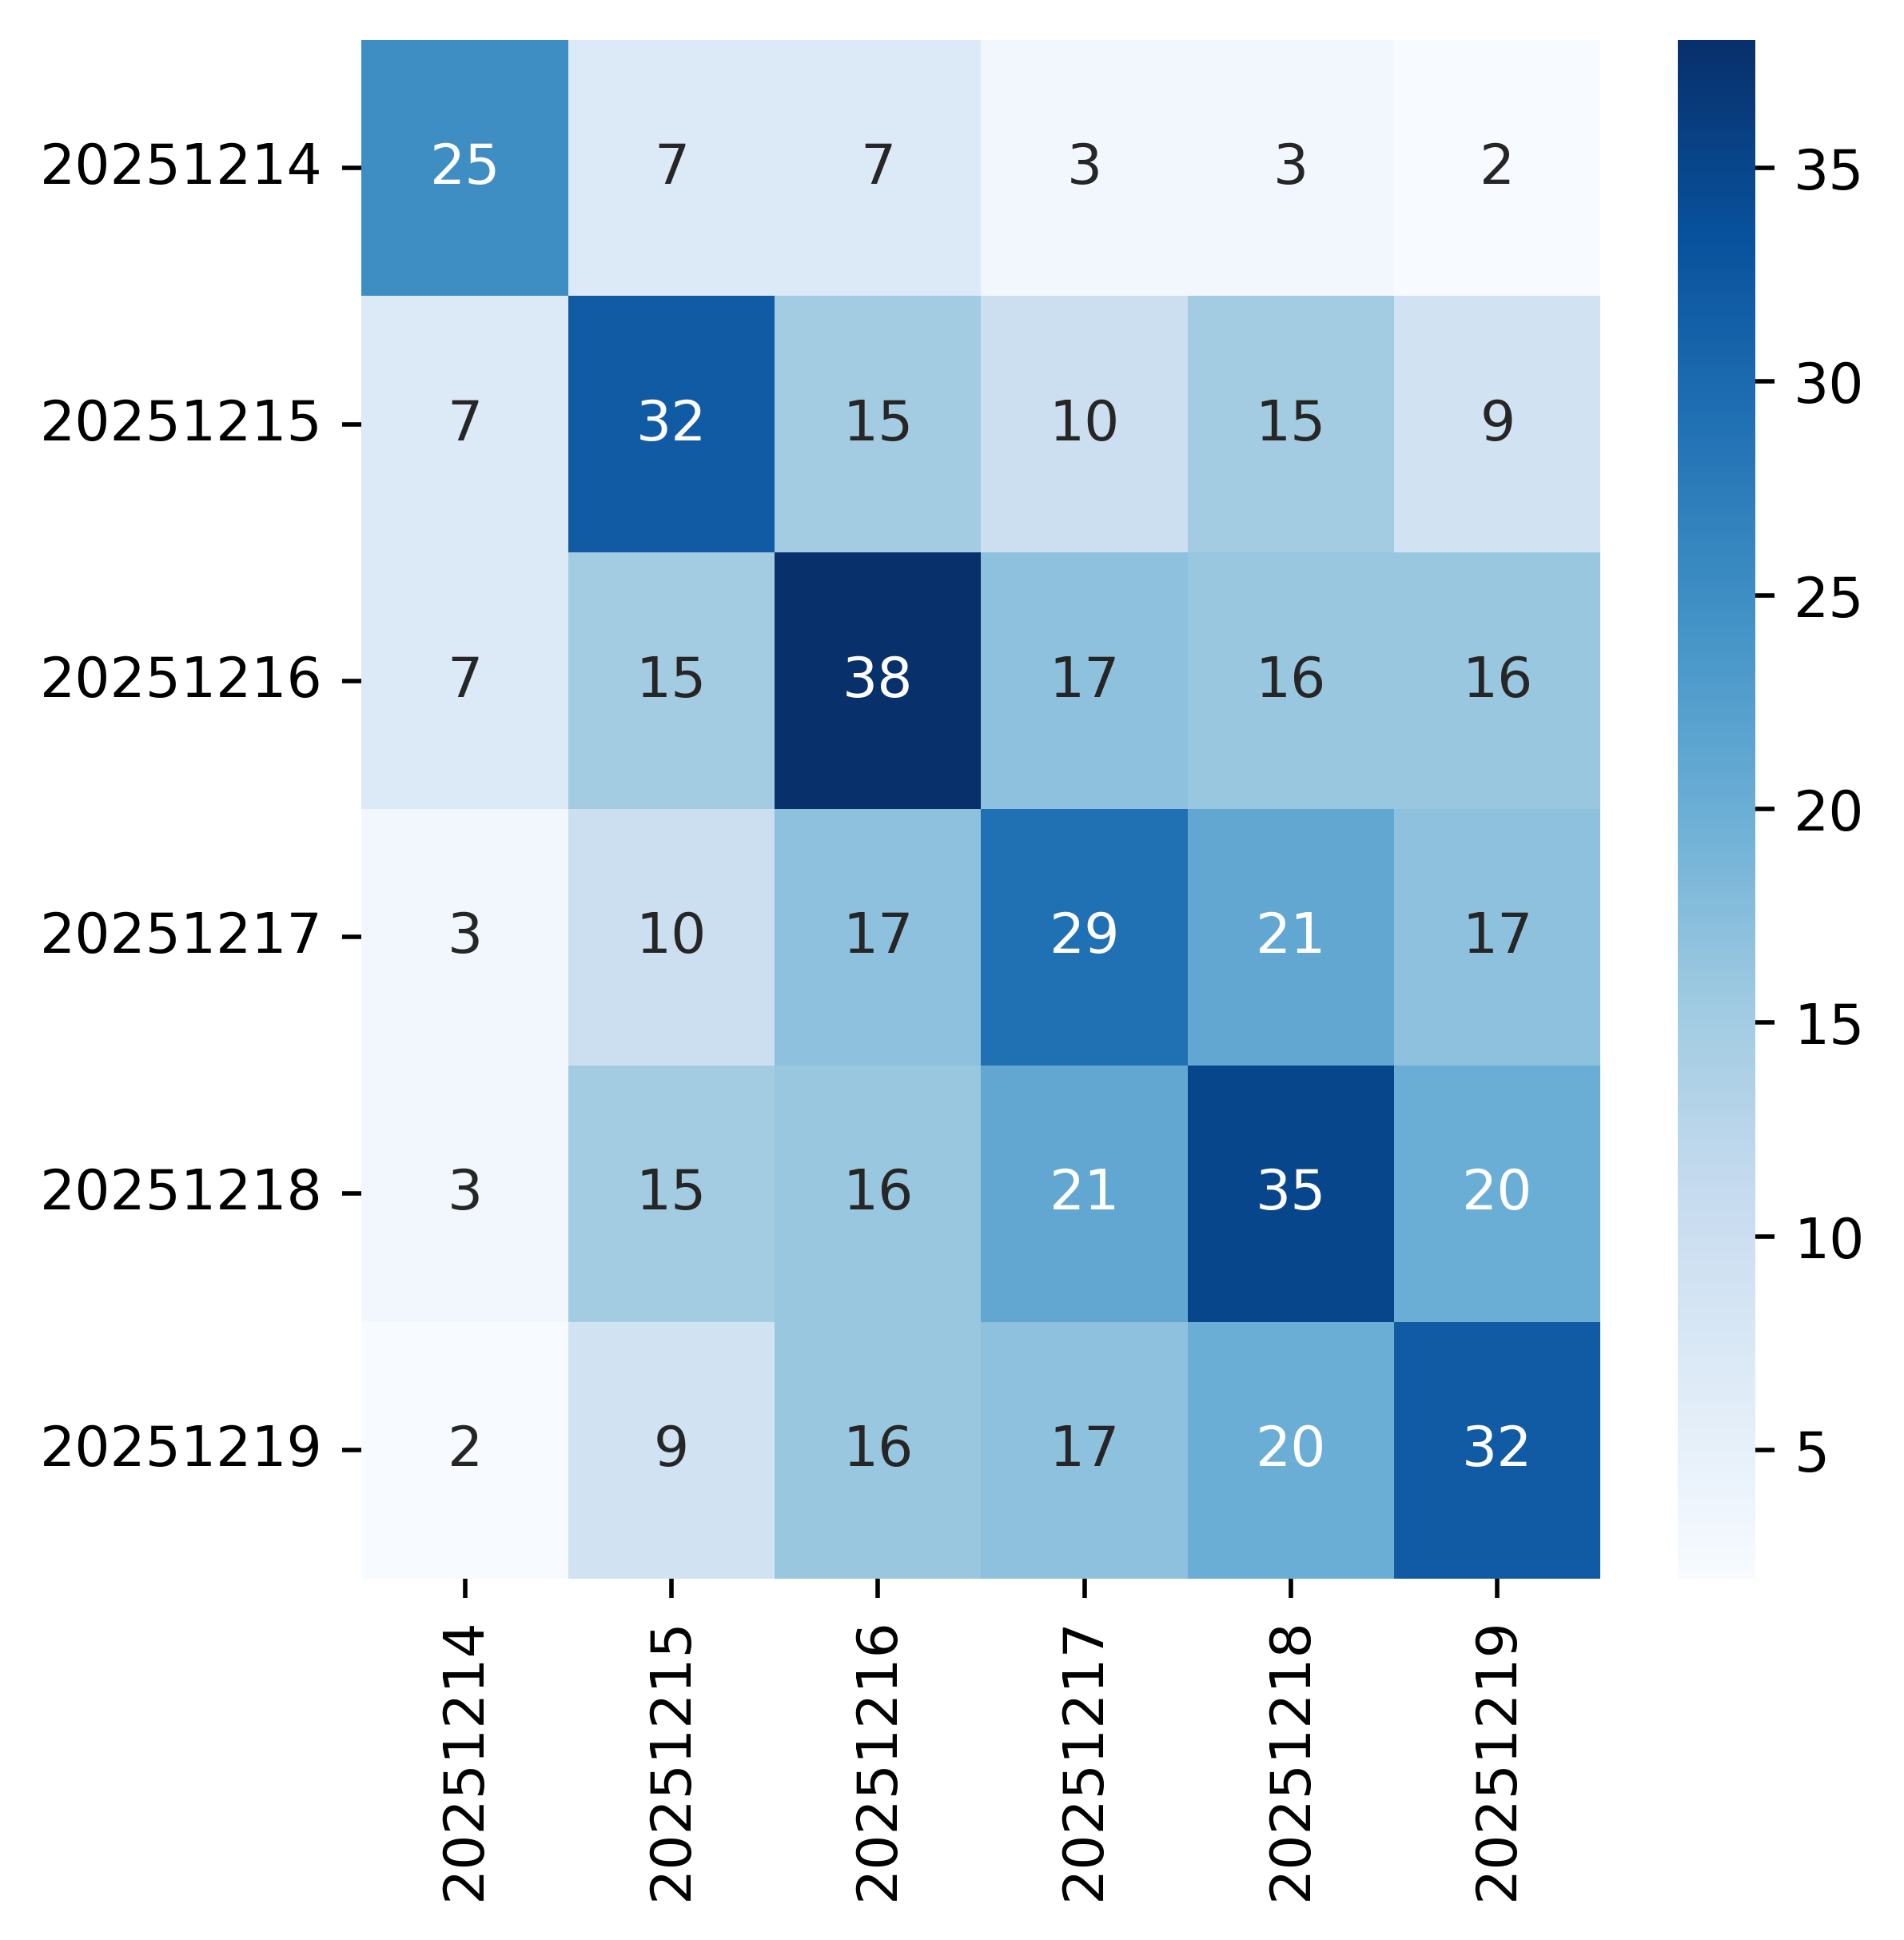

In [19]:
plt.figure(figsize=(5, 5), dpi= 500)
sns.heatmap(match_df, annot=True, cmap = 'Blues')
plt.show()

In [ ]:
# 可选：保存匹配矩阵到CSV
# match_df.to_csv('/media/ubuntu/sda/mouse_test/processed_results/match_matrix_mouse_1.csv')

In [ ]:
# 可选：查看详细的匹配信息（例如，查看第一个日期和第二个日期的详细匹配）
# if len(dates) >= 2:
#     detailed_matches = match_neurons(
#         neuron_inf_dict[dates[0]],
#         neuron_inf_dict[dates[1]],
#         position_threshold=position_threshold,
#         waveform_threshold=waveform_threshold,
#     )
#     print(f"\n{dates[0]} vs {dates[1]} 的详细匹配:")
#     print(detailed_matches.head(10))